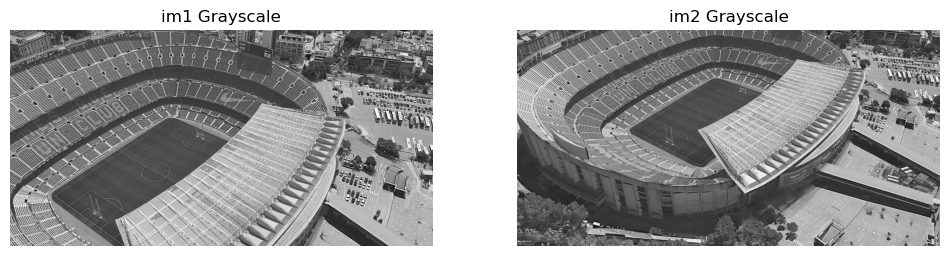

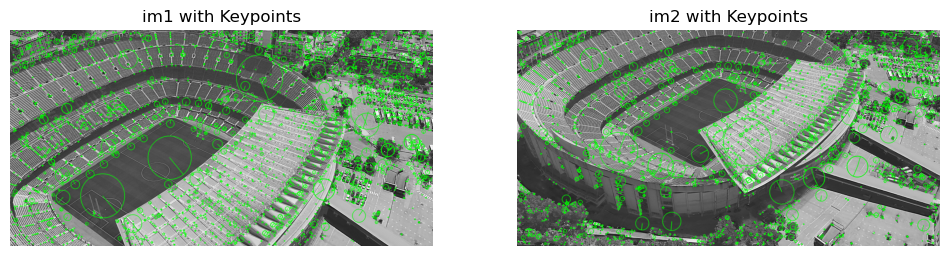

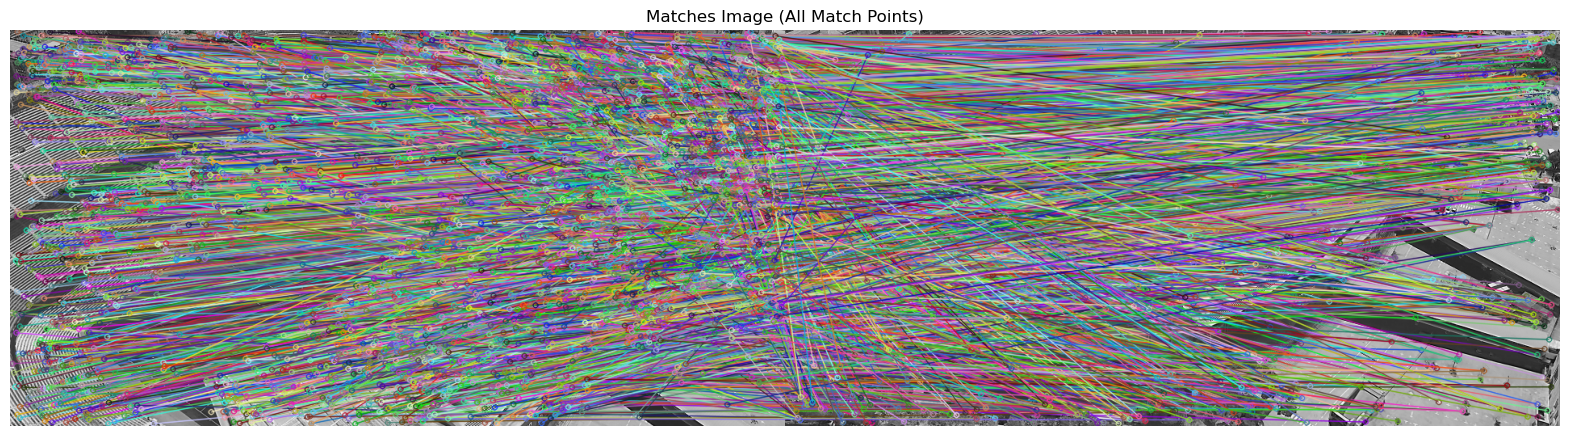

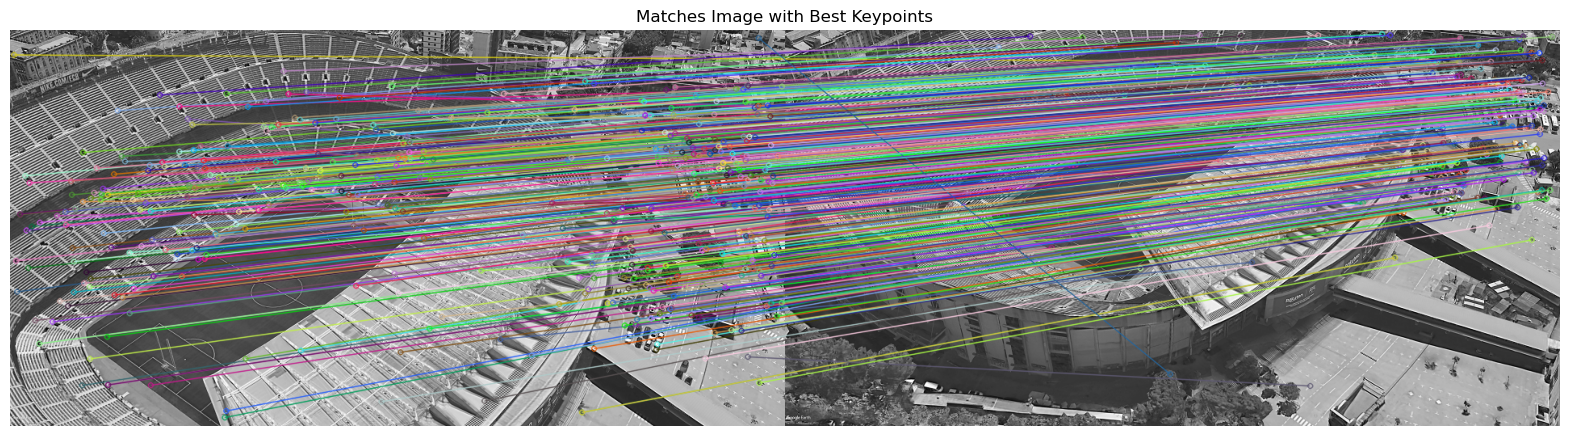

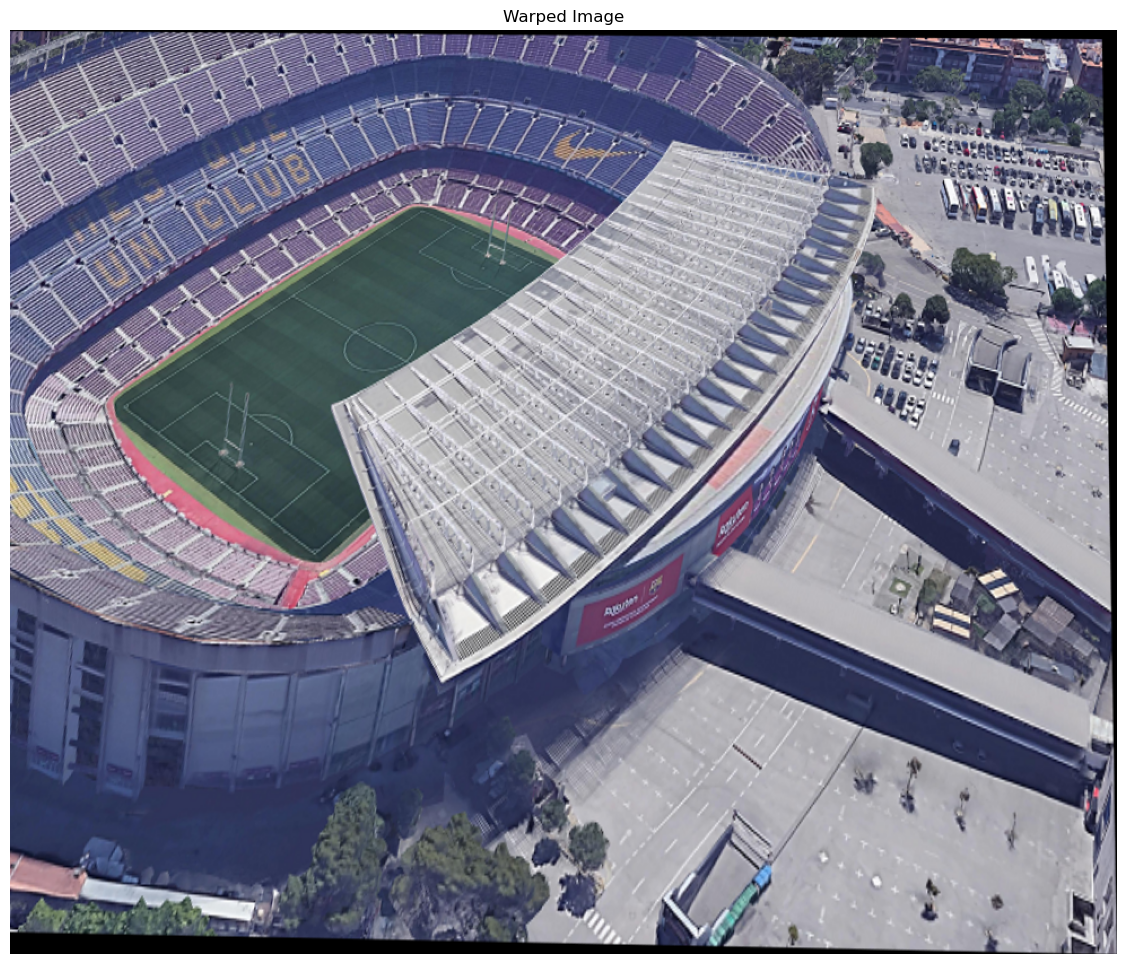

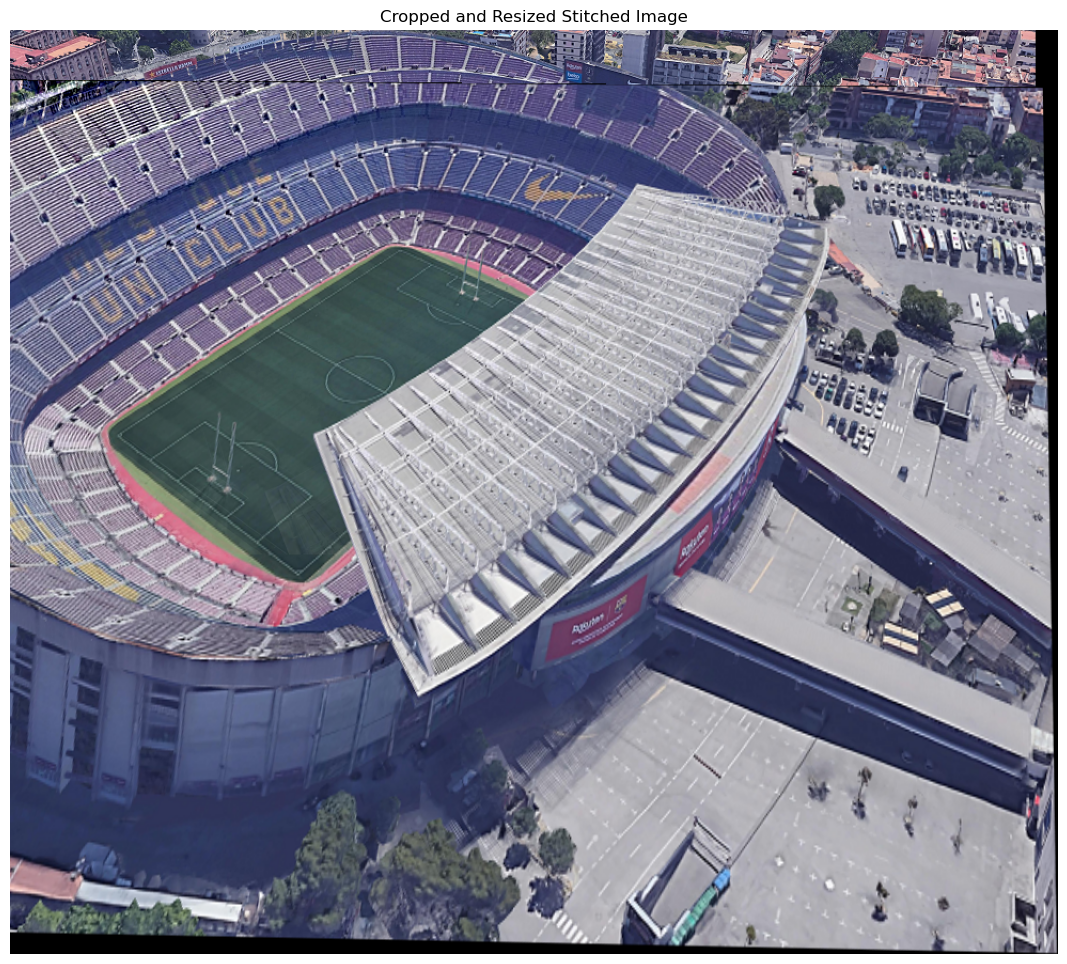

In [1]:
# Importing necessary libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Minimum number of matches required for homography calculation
MIN_MATCH_COUNT = 10 

# Reading the input images
im1 = cv2.imread('campnou_2.png')
im2 = cv2.imread('campnou_3.png')

# Converting the images to grayscale
img1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

# Setting the figure size for the subplot
plt.figure(figsize=(12, 6))

# Plotting the grayscale images in a 1x2 subplot
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('im1 Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('im2 Grayscale')
plt.axis('off')

# Initiating SIFT detector
sift = cv2.SIFT_create()

# Finding keypoints and descriptors using SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Drawing keypoints on both images
im1_keypoints = cv2.drawKeypoints(img1, kp1, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_keypoints = cv2.drawKeypoints(img2, kp2, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Displaying the images with keypoints in a 1x2 subplot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(im1_keypoints)
plt.title('im1 with Keypoints')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im2_keypoints)
plt.title('im2 with Keypoints')
plt.axis('off')

# FLANN parameters for feature matching
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Keepping all match points
all_matches = [m[0] for m in matches]

# Drawing all matches on the images
matches_img = cv2.drawMatches(img1, kp1, img2, kp2, all_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Displaying the matches image using matplotlib
plt.figure(figsize=(20, 6))
plt.imshow(matches_img)
plt.title('Matches Image (All Match Points)')
plt.axis('off')

# Keepping only good matches based on Lowe's ratio test
good = [m for m, n in matches if m.distance < 0.7 * n.distance]

# Keepping the best keypoints
best_keypoints1 = [kp1[match.queryIdx] for match in good]
best_keypoints2 = [kp2[match.trainIdx] for match in good]

# Drawing matches with the best keypoints on the images
matches_img = cv2.drawMatches(img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Displaying the matches image 
plt.figure(figsize=(20, 6))
plt.imshow(matches_img)
plt.title('Matches Image with Best Keypoints')
plt.axis('off')

# Checking if there are enough good matches for homography calculation
if len(good) > MIN_MATCH_COUNT:
    # Getting source and destination points for homography calculation
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Finding homography matrix using RANSAC
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist()
    
    # Warping the resized second image using the inverse homography matrix
    out = cv2.warpPerspective(im2, np.linalg.inv(M), (3*im2.shape[1], 2*im2.shape[0]))

    # Finding bounding box of non-black pixels
    non_black_pixels = np.any(out != 0, axis=2)
    non_black_rows = np.any(non_black_pixels, axis=1)
    non_black_cols = np.any(non_black_pixels, axis=0)

    # Finding the bounding box coordinates
    top_row = np.argmax(non_black_rows)
    bottom_row = len(non_black_rows) - 1 - np.argmax(np.flip(non_black_rows, axis=0))
    left_col = np.argmax(non_black_cols)
    right_col = len(non_black_cols) - 1 - np.argmax(np.flip(non_black_cols, axis=0))

    # Cropping the image to the bounding box
    cropped_out = out[top_row:bottom_row, left_col:right_col]

    plt.figure(figsize=(24, 12))
    plt.imshow(cv2.cvtColor(cropped_out, cv2.COLOR_BGR2RGB))
    plt.title('Warped Image')
    plt.axis('off')
    
    # Averaging pixel values for overlapping region with weighted contribution
    for i in range(im1.shape[0]):
        for j in range(im1.shape[1]):
            if np.all(out[i, j] == 0):  # If the pixel is black in the warped image, use pixel from the first image
                out[i, j] = im1[i, j]
            elif np.all(im1[i, j] != 0):  # If the pixel is not black in the first image, average pixel values with weights
                # Calculating the coordinates of the corresponding pixel in the warped image (out)
                warped_coordinates = np.dot(M, np.array([j, i, 1]))

                # Calculating the normalized coordinates in homogeneous coordinates
                normalized_coordinates = warped_coordinates / warped_coordinates[2]

                # Calculating the Euclidean distance between the original and transformed coordinates
                alpha = np.linalg.norm(normalized_coordinates[:2]) / np.linalg.norm(np.array([j, i]))

                # Beta is the complement of alpha
                beta = 1 - alpha

                # Blending the pixel values with weights and clip the result to the valid range [0, 255]
                out[i, j] = np.clip((alpha * out[i, j] + beta * im1[i, j]).astype(int), 0, 255).astype(np.uint8)
                

    # Finding bounding box of non-black pixels
    non_black_pixels = np.any(out != 0, axis=2)
    non_black_rows = np.any(non_black_pixels, axis=1)
    non_black_cols = np.any(non_black_pixels, axis=0)

    # Cropping the image to the bounding box
    final_result = out[non_black_rows][:, non_black_cols]

    # Displaying the cropped and resized stitched image
    plt.figure(figsize=(24, 12))
    plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
    plt.title('Cropped and Resized Stitched Image')
    plt.axis('off')
    plt.show()
else:
    print("Not enough good matches found.")
